In [1]:
from google.colab import files
uploaded = files.upload()

Saving data.zip to data.zip


In [2]:
import zipfile
import os

zip_path = '/content/data.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam, SGD

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

import seaborn as sns

In [4]:
DATASET_PATH = '/content/dataset/data/natural_images'

In [5]:
classes = os.listdir(DATASET_PATH)

image_count = {}

total_images = 0

for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    count = len(os.listdir(cls_path))
    image_count[cls] = count
    total_images += count

print("Total Images:", total_images)
print(image_count)

Total Images: 6899
{'dog': 702, 'fruit': 1000, 'person': 986, 'motorbike': 788, 'flower': 843, 'cat': 885, 'airplane': 727, 'car': 968}


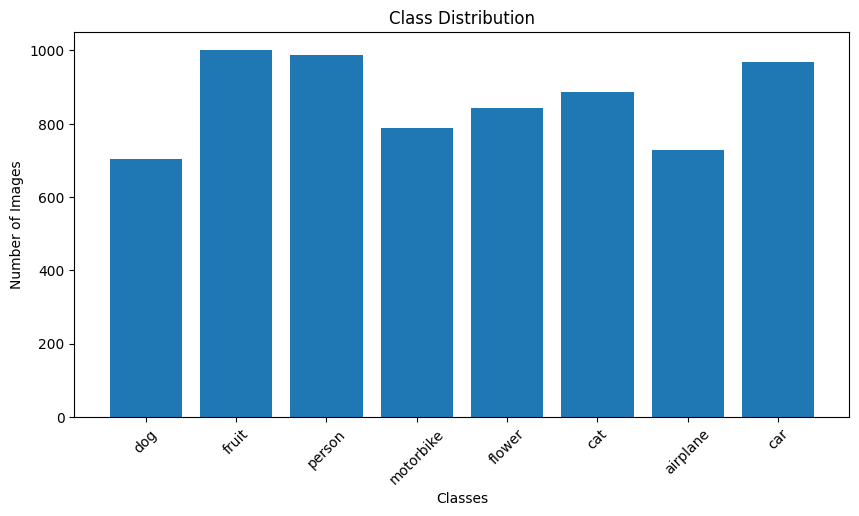

In [6]:
plt.figure(figsize=(10,5))
plt.bar(image_count.keys(), image_count.values())
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

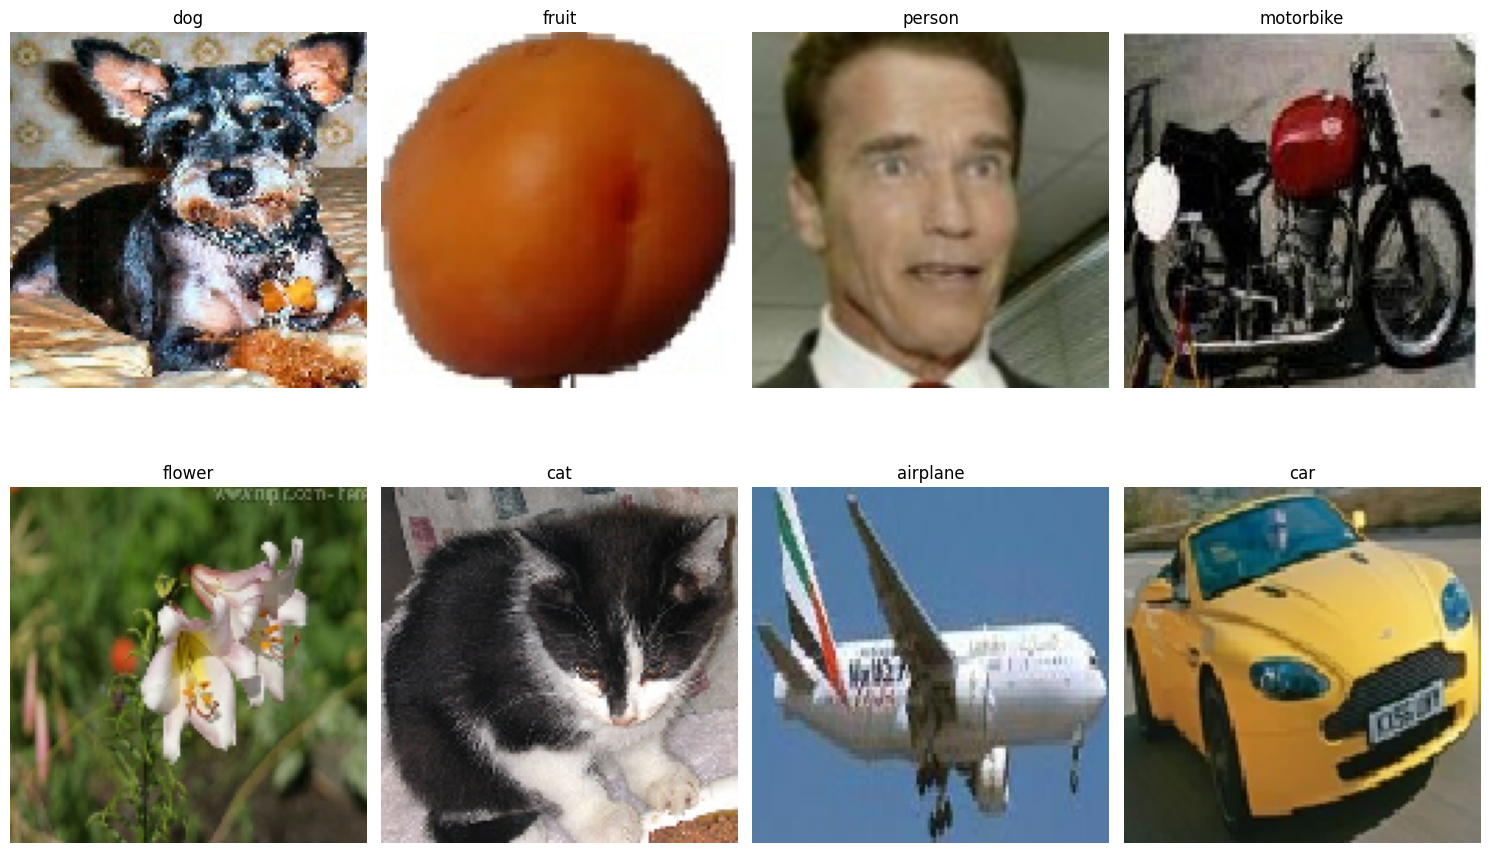

In [7]:
import random
from tensorflow.keras.preprocessing import image

plt.figure(figsize=(15,10))

for i, cls in enumerate(classes):
    img_name = random.choice(os.listdir(os.path.join(DATASET_PATH, cls)))
    img_path = os.path.join(DATASET_PATH, cls, img_name)

    img = image.load_img(img_path, target_size=(128,128))

    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [8]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 5522 images belonging to 8 classes.
Found 1377 images belonging to 8 classes.


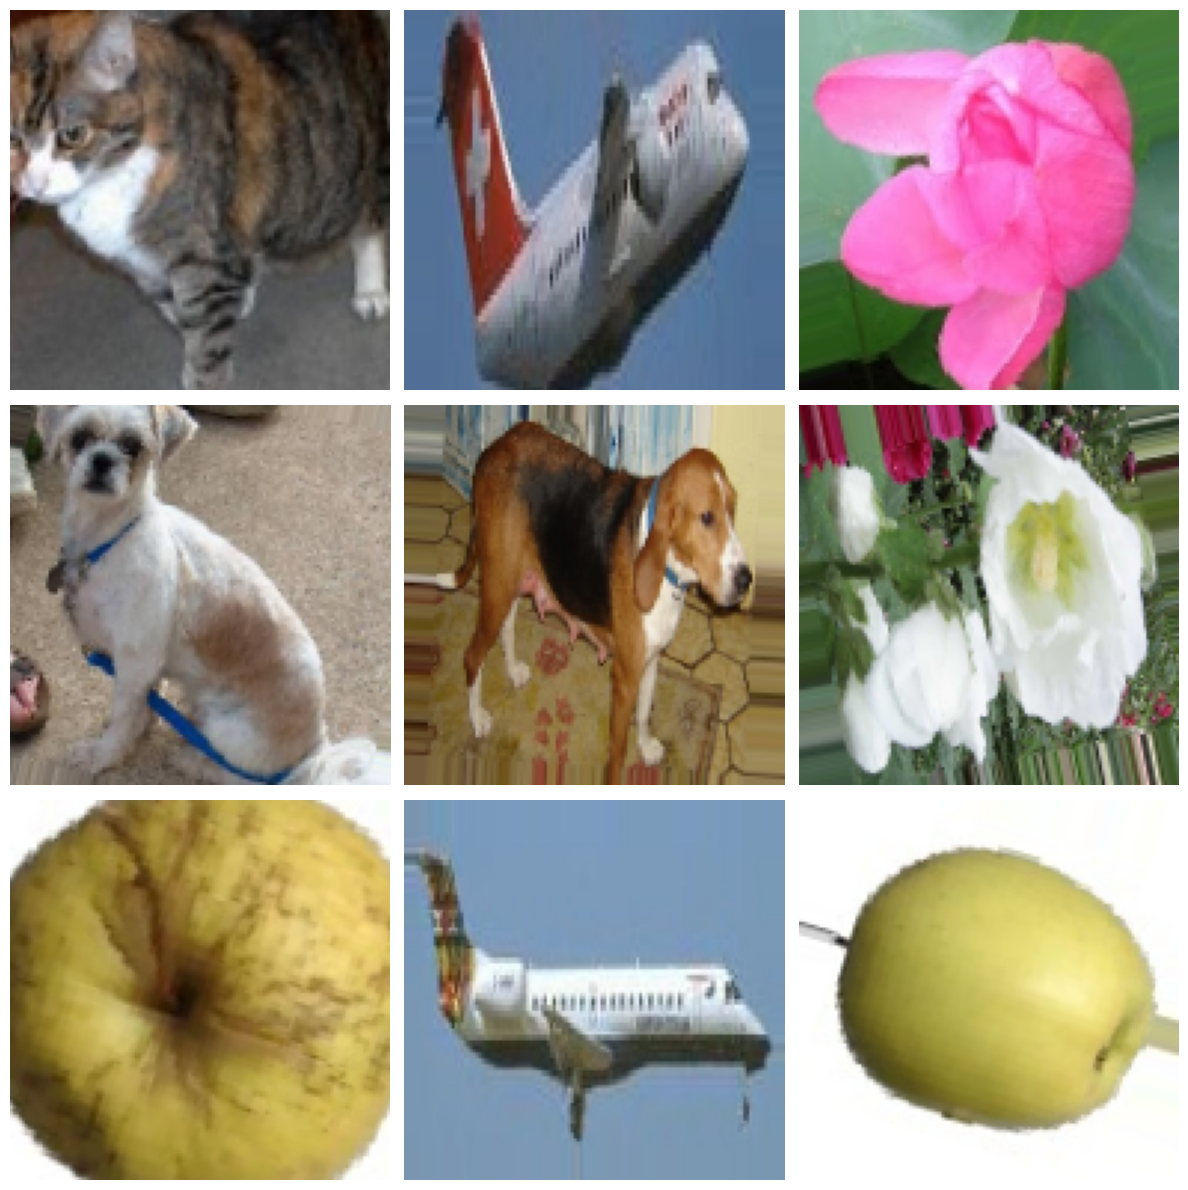

In [9]:
images, labels = next(train_generator)

plt.figure(figsize=(12,12))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [10]:
baseline_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),

    Dense(8, activation='softmax')
])

baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,557,704 (25.02 MB)

 Trainable params: 6,557,704 (25.02 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
history_baseline = baseline_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 48s 236ms/step - accuracy: 0.6474 - loss: 0.9361 - val_accuracy: 0.7749 - val_loss: 0.5855
Epoch 2/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 36s 208ms/step - accuracy: 0.8430 - loss: 0.4140 - val_accuracy: 0.8272 - val_loss: 0.5377
Epoch 3/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 34s 197ms/step - accuracy: 0.8754 - loss: 0.3423 - val_accuracy: 0.8809 - val_loss: 0.3550
Epoch 4/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 35s 203ms/step - accuracy: 0.8828 - loss: 0.3009 - val_accuracy: 0.8671 - val_loss: 0.3766
Epoch 5/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 36s 206ms/step - accuracy: 0.9069 - loss: 0.2413 - val_accuracy: 0.8991 - val_loss: 0.2910
Epoch 6/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 36s 207ms/step - accuracy: 0.9210 - loss: 0.2140 - val_accuracy: 0.8838 - val_loss: 0.3652
Epoch 7/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 34s 199ms/step - accuracy: 0.9203 - loss: 0.2193 - val_accuracy: 0.8947 - val_loss: 0.2896
Epoch 8/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 34s 199ms/step - accuracy: 0.9276 - loss: 0

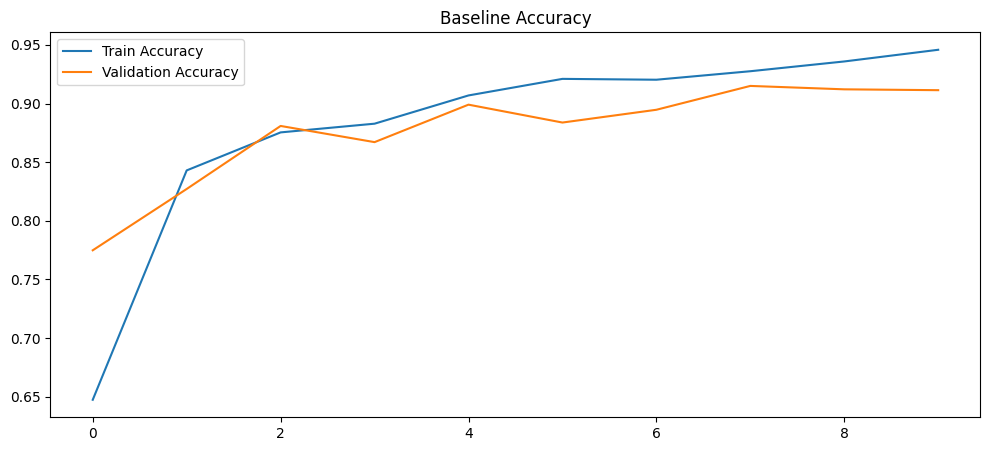

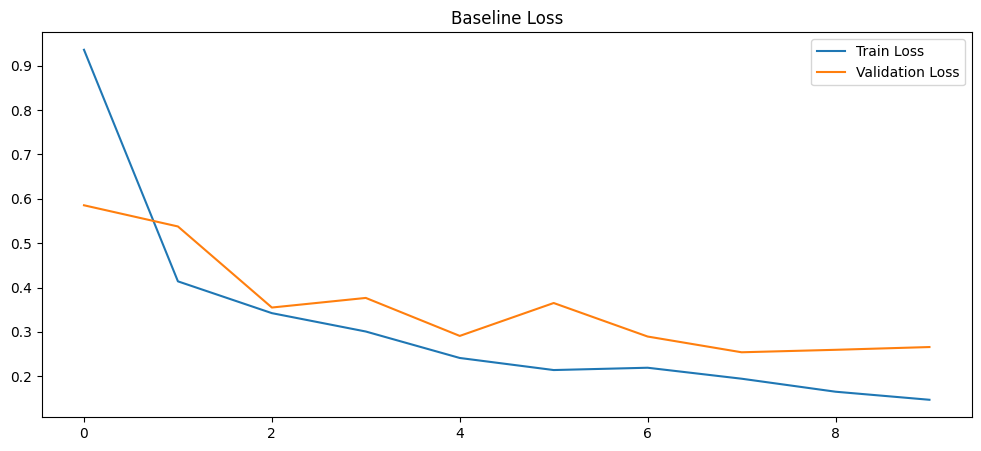

In [13]:
plt.figure(figsize=(12,5))

plt.plot(history_baseline.history['accuracy'], label='Train Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Baseline Accuracy')
plt.show()
plt.figure(figsize=(12,5))

plt.plot(history_baseline.history['loss'], label='Train Loss')
plt.plot(history_baseline.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Baseline Loss')
plt.show()

In [14]:
baseline_loss, baseline_acc = baseline_model.evaluate(validation_generator)

print("Baseline Accuracy:", baseline_acc)

44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 204ms/step - accuracy: 0.9194 - loss: 0.2562
Baseline Accuracy: 0.9193899631500244


In [ ]:
predictions = baseline_model.predict(validation_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = validation_generator.classes

print(classification_report(y_true, y_pred))

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix - Baseline')
plt.show()

In [ ]:
deep_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(512, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(128, activation='relu'),

    Dense(8, activation='softmax')
])


deep_model.summary()

In [ ]:
deep_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_deep = deep_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

In [ ]:
deep_loss, deep_acc = deep_model.evaluate(validation_generator)

print("Deeper Model Accuracy:", deep_acc)

In [ ]:
sgd_model = tf.keras.models.clone_model(deep_model)

sgd_model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = sgd_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

base_model.trainable = False

In [ ]:
transfer_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(8, activation='softmax')
])

transfer_model.summary()

In [ ]:
transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_transfer = transfer_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

In [ ]:
transfer_loss, transfer_acc = transfer_model.evaluate(validation_generator)

print("Transfer Learning Accuracy:", transfer_acc)

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = '/content/dataset/data/natural_images/car/car_0001.jpg'

img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = transfer_model.predict(img_array)

class_names = list(train_generator.class_indices.keys())
predicted_class = class_names[np.argmax(prediction)]

plt.imshow(img)
plt.title(f'Predicted: {predicted_class}')
plt.axis('off')
plt.show()

In [ ]:
transfer_model.save('vision_model.h5')